# Day 1.4 — Tool Calling
**Tool calling does not let the model run code.** The model receives a *description* of a
function and may reply with the tool's name and arguments. Your program validates that request,
runs the real function, and sends the result back as a `tool` message. The model never touches Python.

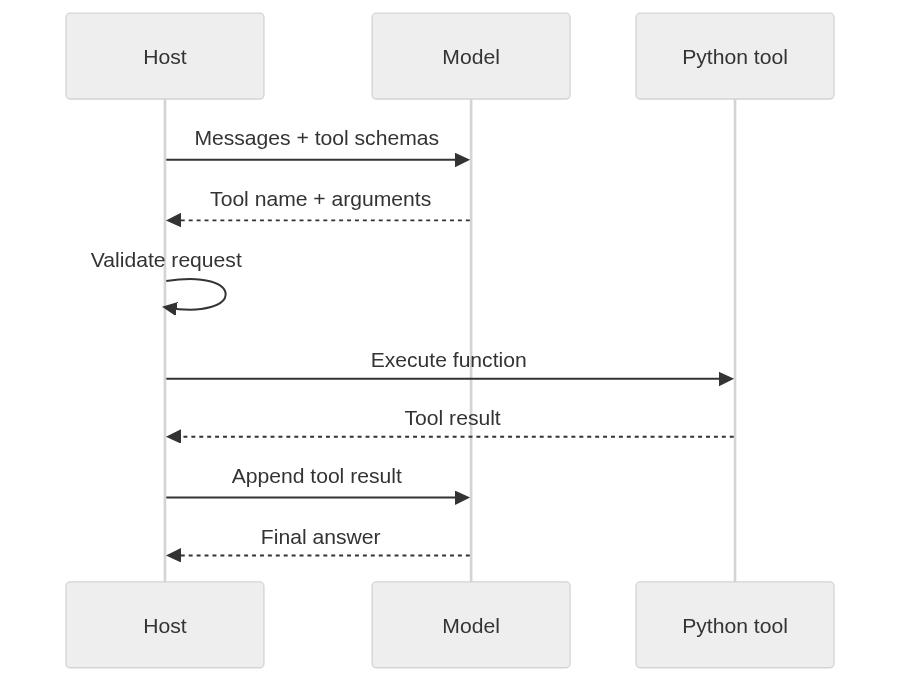

*D03 — host sends messages and tool schemas; model returns a tool request; host validates, executes, and returns the result*

### Step 1 — A calculator that is safe to expose

Never `eval()` model output. This calculator parses the expression into a syntax tree and allows
only numbers and arithmetic operators, so `__import__('os')` is rejected before anything runs.

In [ ]:
import ast, operator

_OPERATORS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul,
              ast.Div: operator.truediv, ast.Pow: operator.pow, ast.USub: operator.neg}

def _evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in _OPERATORS:
        left, right = _evaluate(node.left), _evaluate(node.right)
        if isinstance(node.op, ast.Pow) and abs(right) > 10:
            raise ValueError("exponent limited to 10")
        return _OPERATORS[type(node.op)](left, right)
    if isinstance(node, ast.UnaryOp) and type(node.op) in _OPERATORS:
        return _OPERATORS[type(node.op)](_evaluate(node.operand))
    raise ValueError("only numbers and + - * / ** are allowed")

def calculate(expression: str) -> str:
    """Evaluate basic arithmetic WITHOUT eval()."""
    result = _evaluate(ast.parse(expression, mode="eval").body)
    return str(int(result)) if float(result).is_integer() else str(result)

print("37 * 19            ->", calculate("37 * 19"))
try:
    calculate("__import__('os').system('ls')")
except ValueError as error:
    print("malicious input     -> rejected:", error)

### Step 2 — Describe the tool to the model, and validate its arguments

A tool needs three things: a **schema** the model sees, a Pydantic **argument model** we validate
with, and the **function** we run. `make_tool` bundles them; `execute_tool_call` is the only
place a model request can turn into execution.

In [ ]:
class CalculatorArgs(BaseModel):
    expression: str = Field(min_length=1, max_length=100)

def make_tool(name, description, function, arg_model):
    """Bundle schema (what the model sees), validator, and function (what we run)."""
    return {"name": name, "function": function, "arg_model": arg_model,
            "schema": {"type": "function", "function": {
                "name": name, "description": description,
                "parameters": make_strict(arg_model.model_json_schema())}}}

def execute_tool_call(call, tools):
    """Validate a model's tool request and run it. Returns the observation as text."""
    tool = tools.get(call["name"])
    if tool is None:
        return f"Tool error: unknown tool '{call['name']}'"          # the model invented a name
    try:
        arguments = tool["arg_model"].model_validate(call["arguments"])  # 1. validate
        return tool["function"](**arguments.model_dump())               # 2. execute
    except ValidationError as error:                                    # 3a. bad arguments: say which
        first = error.errors()[0]
        return f"Tool error: argument '{'.'.join(map(str, first['loc'])) or 'input'}' {first['msg']}"
    except (ValueError, SyntaxError, ZeroDivisionError) as error:
        return f"Tool error: {str(error).splitlines()[0]}"               # 3b. report, never crash

TOOLS = {"calculator": make_tool("calculator", "Evaluate basic arithmetic. Use it instead of doing arithmetic mentally.",
                                 calculate, CalculatorArgs)}
print(json.dumps(TOOLS["calculator"]["schema"], indent=2))

### Step 3 — One complete tool turn

Watch the four hand-offs: the model *requests*, we *validate and execute*, we *append* the
observation as a `tool` message, the model *answers*.

In [ ]:
def assistant_message(reply):
    """Convert a chat() reply into the message format the API expects back in the history."""
    message = {"role": "assistant", "content": reply["content"]}
    if reply["tool_calls"]:
        message["tool_calls"] = [{"id": c["id"], "type": "function",
                                  "function": {"name": c["name"], "arguments": json.dumps(c["arguments"])}}
                                 for c in reply["tool_calls"]]
    return message

history = [{"role": "system", "content": "Use the calculator for any arithmetic."},
           {"role": "user", "content": "What is 37 * 19?"}]
tool_schemas = [t["schema"] for t in TOOLS.values()]

reply = chat(history, tools=tool_schemas)
print("1. model REQUESTS  :", reply["tool_calls"])

history.append(assistant_message(reply))
for call in reply["tool_calls"]:
    observation = execute_tool_call(call, TOOLS)                       # WE run it
    print("2. host EXECUTES   :", call["name"], call["arguments"], "->", observation)
    history.append({"role": "tool", "tool_call_id": call["id"], "content": observation})

final = chat(history, tools=tool_schemas)
print("3. model ANSWERS   :", final["content"])
print("\nMessages now:", [m["role"] for m in history])

### Step 4 — Break it: requests our code refuses

The model can invent a tool, send the wrong field, or smuggle code. None of it reaches the function.

In [ ]:
bad_requests = [
    {"id": "x1", "name": "delete_files", "arguments": {"path": "/"}},                 # invented tool
    {"id": "x2", "name": "calculator",   "arguments": {"expr": "1 + 1"}},             # wrong field name
    {"id": "x3", "name": "calculator",   "arguments": {"expression": "__import__('os')"}},  # code smuggling
    {"id": "x4", "name": "calculator",   "arguments": {"expression": "2 ** 999"}},    # resource abuse
]
for call in bad_requests:
    print(f"{call['name']:<14} {str(call['arguments']):<40} -> {execute_tool_call(call, TOOLS)}")

### Checkpoint

**1. Which line of code actually multiplied 37 by 19?**

<details><summary>Show answer</summary>

`tool['function'](**arguments.model_dump())` inside `execute_tool_call`, called by *our* loop. The model only produced the request `{'expression': '37*19'}`.

</details>

**2. Why validate arguments with a Pydantic model when the provider already saw a strict schema?**

<details><summary>Show answer</summary>

The schema is advice to the model; the model can still produce anything, and some providers do not enforce it. Validation in our code is what stands between a bad request and a real function call.

</details>

### Recap

- **Limitation seen:** the model cannot act, and its requests cannot be trusted blindly.
- **Layer added:** tool schema + argument validation + host-side execution + `tool` message.
- **Evidence:** four malformed requests were refused before any function ran.